# Imports

In [1]:
import numpy as np
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import PIL
import PIL.Image
import os
import pathlib
import math
print(tf.__version__)

2025-06-03 06:02:13.735560: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748930533.925638      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748930533.983456      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


2.18.0


In [2]:
# # import kagglehub
# import os
# # Download latest version
# # path = kagglehub.dataset_download("nafin59/monkeypox-skin-lesion-dataset")
# # print("Path to dataset files:", path)
# # path = kagglehub.dataset_download("dipuiucse/monkeypoxskinimagedataset")


# # files = os.listdir('../input/monkeypox-skin-lesion-dataset/Fold1/Fold1/Fold1/Test')
# files = os.listdir('../input/monkeypoxskinimagedataset/Monkeypox Skin Image Dataset')

# print(files)

# Hyper-parameters

In [3]:
batch_size = 32
img_height = 224
img_width = 224
lr_rate = 1e-3
lr_mode = 'cos'
epochs = 15
data_dir = pathlib.Path('/kaggle/input/mpox-skin-lesion-dataset-version-20-msld-v20/Augmented Images/Augmented Images/FOLDS_AUG/fold1_AUG/Train').with_suffix('')

# Data preprocessing

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

class_names = train_ds.class_names
print(class_names)

Found 7518 files belonging to 6 classes.
Using 6015 files for training.


I0000 00:00:1748930559.057377      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1748930559.058033      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 7518 files belonging to 6 classes.
Using 1503 files for validation.
['Chickenpox', 'Cowpox', 'HFMD', 'Healthy', 'Measles', 'Monkeypox']


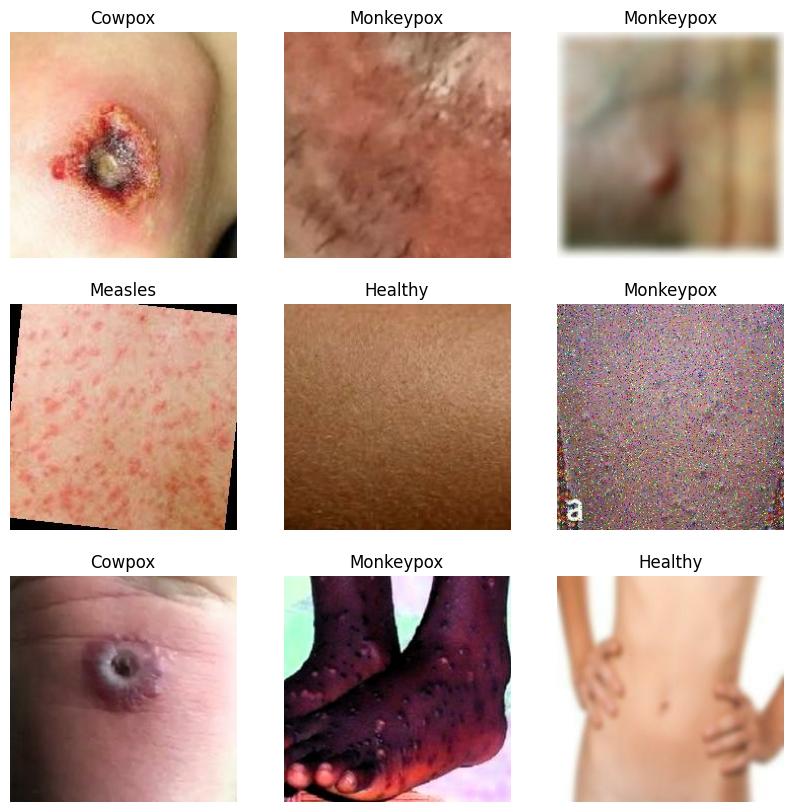

In [5]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [6]:
for image_batch, labels_batch in train_ds:
    print(image_batch.shape)
    print(labels_batch.shape)
    break

(32, 224, 224, 3)
(32,)


## Autotone

In [7]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

## Normalization

In [8]:
normalization_layer = tf.keras.layers.Rescaling(1./255)
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixel values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image))

0.0 1.0


In [9]:
base_model = keras.applications.ResNet50(
    weights='imagenet',  # Load weights pre-trained on ImageNet.
    input_shape=(img_width, img_height, 3),
    include_top=False)  # Do not include the ImageNet classifier at the top.

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
base_model.trainable = False

In [11]:
inputs = keras.Input(shape=(img_width, img_height, 3))
x = base_model(inputs, training=False)
x = keras.layers.Conv2D(512, 3, padding='same', activation='relu')(x)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dense(256, activation='relu')(x)
outputs = keras.layers.Dense(6)(x)

model = keras.Model(inputs, outputs)

In [12]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 7, 7, 512)           │       9,437,696 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │           1,542 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 33,158,278 (126.49 MB)

 Trainable params: 9,570,566 (36.51 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## LR Schedule

In [13]:
def get_lr_callback(batch_size=8, mode='cos', epochs=10, plot=False):
    lr_start, lr_max, lr_min = 5e-5, 6e-6 * batch_size, 1e-5
    lr_ramp_ep, lr_sus_ep, lr_decay = 3, 0, 0.75

    def lrfn(epoch):  # Learning rate update function
        if epoch < lr_ramp_ep: lr = (lr_max - lr_start) / lr_ramp_ep * epoch + lr_start
        elif epoch < lr_ramp_ep + lr_sus_ep: lr = lr_max
        elif mode == 'exp': lr = (lr_max - lr_min) * lr_decay**(epoch - lr_ramp_ep - lr_sus_ep) + lr_min
        elif mode == 'step': lr = lr_max * lr_decay**((epoch - lr_ramp_ep - lr_sus_ep) // 2)
        elif mode == 'cos':
            decay_total_epochs, decay_epoch_index = epochs - lr_ramp_ep - lr_sus_ep + 3, epoch - lr_ramp_ep - lr_sus_ep
            phase = math.pi * decay_epoch_index / decay_total_epochs
            lr = (lr_max - lr_min) * 0.5 * (1 + math.cos(phase)) + lr_min
        return lr

    if plot:  # Plot lr curve if plot is True
        plt.figure(figsize=(10, 5))
        plt.plot(np.arange(epochs), [lrfn(epoch) for epoch in np.arange(epochs)], marker='o')
        plt.xlabel('epoch'); plt.ylabel('lr')
        plt.title('LR Scheduler')
        plt.show()

    return keras.callbacks.LearningRateScheduler(lrfn, verbose=False)  # Create lr callback

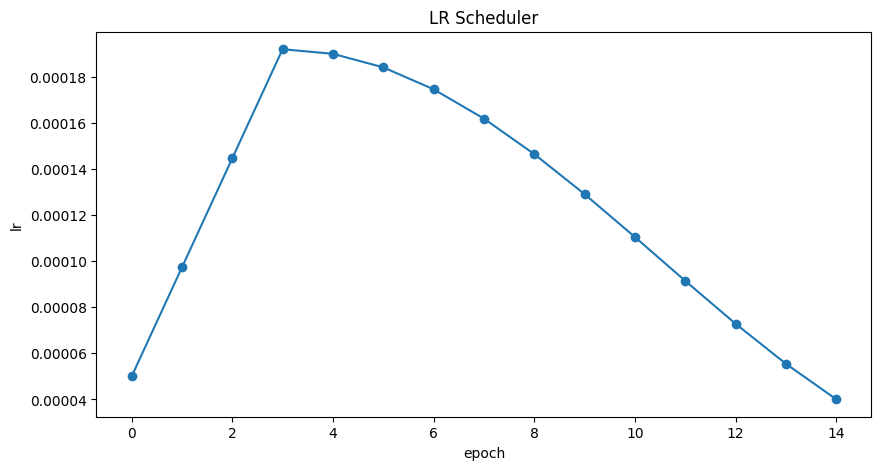

In [14]:
lr_cb = get_lr_callback(batch_size, mode=lr_mode, plot=True, epochs=epochs)

In [15]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr_rate),
              loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [16]:
history = model.fit(
    train_ds,
    epochs=epochs,
    callbacks=[early_stopping, lr_cb],
    validation_data=train_ds)

Epoch 1/15


I0000 00:00:1748930578.054945      99 service.cc:148] XLA service 0x79d5bc002850 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748930578.055628      99 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1748930578.055647      99 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1748930579.466072      99 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/188 ━━━━━━━━━━━━━━━━━━━━ 59:21 19s/step - accuracy: 0.0000e+00 - loss: 2.5818

I0000 00:00:1748930586.461945      99 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


188/188 ━━━━━━━━━━━━━━━━━━━━ 74s 293ms/step - accuracy: 0.6862 - loss: 0.8856 - val_accuracy: 0.9140 - val_loss: 0.2436 - learning_rate: 5.0000e-05
Epoch 2/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 40s 211ms/step - accuracy: 0.9109 - loss: 0.2439 - val_accuracy: 0.9613 - val_loss: 0.1163 - learning_rate: 9.7333e-05
Epoch 3/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 42s 224ms/step - accuracy: 0.9544 - loss: 0.1370 - val_accuracy: 0.9653 - val_loss: 0.1025 - learning_rate: 1.4467e-04
Epoch 4/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 41s 217ms/step - accuracy: 0.9567 - loss: 0.1280 - val_accuracy: 0.9486 - val_loss: 0.1525 - learning_rate: 1.9200e-04
Epoch 5/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 41s 221ms/step - accuracy: 0.9453 - loss: 0.1514 - val_accuracy: 0.9771 - val_loss: 0.0629 - learning_rate: 1.9001e-04
Epoch 6/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 41s 219ms/step - accuracy: 0.9787 - loss: 0.0572 - val_accuracy: 0.9711 - val_loss: 0.0753 - learning_rate: 1.8413e-04
Epoch 7/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 41s 219ms/step - 

# Evaluation

# Plot training results

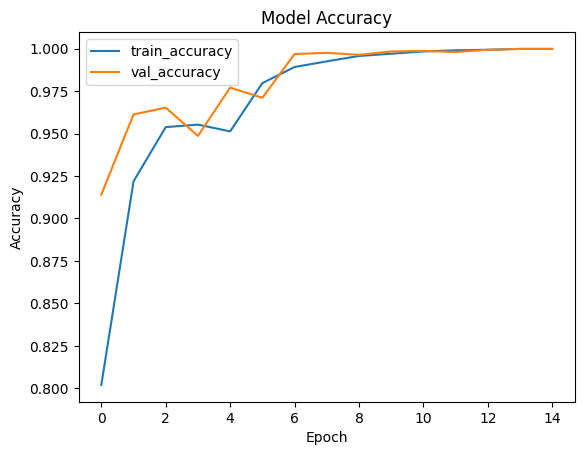

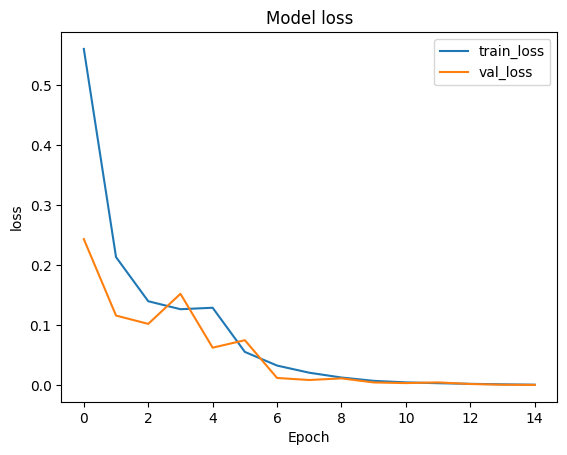

In [17]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['train_accuracy', 'val_accuracy'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('loss')
plt.xlabel('Epoch')
plt.legend(['train_loss', 'val_loss'])
plt.show()

47/47 ━━━━━━━━━━━━━━━━━━━━ 13s 192ms/step
Confusion Matrix:
[[126   1   0   0   0  13]
 [  2 116   0   1   0   1]
 [  1   0 339   1   0   4]
 [  0   0   3 244   3   1]
 [  1   0   0   3  92   2]
 [  0   2   2   2   2 541]]

Classification Report:
               precision    recall  f1-score   support

  Chickenpox     0.9692    0.9000    0.9333       140
      Cowpox     0.9748    0.9667    0.9707       120
        HFMD     0.9855    0.9826    0.9840       345
     Healthy     0.9721    0.9721    0.9721       251
     Measles     0.9485    0.9388    0.9436        98
   Monkeypox     0.9626    0.9854    0.9739       549

    accuracy                         0.9701      1503
   macro avg     0.9688    0.9576    0.9629      1503
weighted avg     0.9701    0.9701    0.9699      1503


Macro-Averaged F1 Score: 0.9629


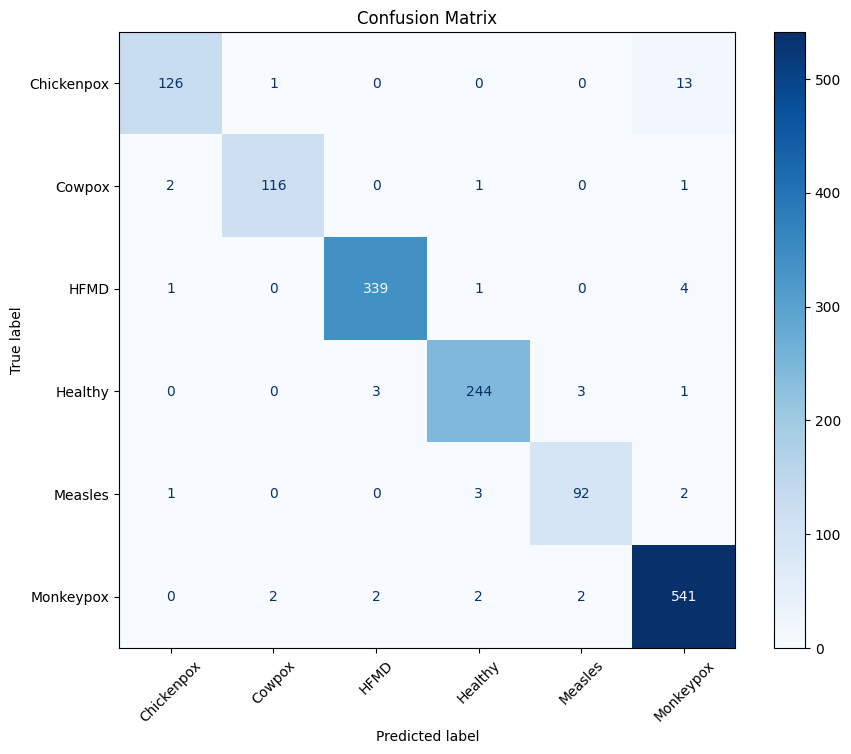

In [18]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, f1_score
import numpy as np

# Step 1: Get validation data
val_images = []
val_labels = []

for images, labels in val_ds.unbatch():
    val_images.append(images.numpy())
    val_labels.append(labels.numpy())

val_images = np.array(val_images)
val_labels = np.array(val_labels)

# Step 2: Predict (convert logits to probabilities, then get class indices)
logits = model.predict(val_images, batch_size=batch_size)
pred_labels = np.argmax(tf.nn.softmax(logits, axis=1), axis=1)

# Step 3: Confusion Matrix
cm = confusion_matrix(val_labels, pred_labels)
print("Confusion Matrix:")
print(cm)

# Step 4: Classification Report with macro F1
report = classification_report(val_labels, pred_labels, target_names=class_names, digits=4)
print("\nClassification Report:\n", report)

# Step 5: F1 Score (macro)
macro_f1 = f1_score(val_labels, pred_labels, average='macro')
print("\nMacro-Averaged F1 Score: {:.4f}".format(macro_f1))

# Step 6: Plot Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

## Testing

### Test 1

In [19]:
test_data_dir = '/kaggle/input/mpox-skin-lesion-dataset-version-20-msld-v20/Original Images/Original Images/FOLDS/fold1/Valid'
test_ds = tf.keras.utils.image_dataset_from_directory(
  test_data_dir,
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

model.evaluate(test_ds)

Found 144 files belonging to 6 classes.
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.7284 - loss: 1.7305 


[1.8550063371658325, 0.7361111044883728]

### Test 2

In [20]:
test_data_dir = '/kaggle/input/mpox-skin-lesion-dataset-version-20-msld-v20/Original Images/Original Images/FOLDS/fold1/Test'
test_ds = tf.keras.utils.image_dataset_from_directory(
  test_data_dir,
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

model.evaluate(test_ds)

Found 74 files belonging to 6 classes.
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.8049 - loss: 1.4608  


[1.6188446283340454, 0.7972972989082336]

## Test 3

In [21]:
test_data_dir = '/kaggle/input/mpox-skin-lesion-dataset-version-20-msld-v20/Original Images/Original Images/FOLDS/fold2/Valid'
test_ds = tf.keras.utils.image_dataset_from_directory(
  test_data_dir,
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

model.evaluate(test_ds)

Found 164 files belonging to 6 classes.
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 711ms/step - accuracy: 0.9899 - loss: 0.0624


[0.09645484387874603, 0.9878048896789551]

## Test 4

In [22]:
test_data_dir = '/kaggle/input/mpox-skin-lesion-dataset-version-20-msld-v20/Original Images/Original Images/FOLDS/fold3/Valid'
test_ds = tf.keras.utils.image_dataset_from_directory(
  test_data_dir,
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

model.evaluate(test_ds)

Found 153 files belonging to 6 classes.
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.9396 - loss: 0.3291  


[0.3535343408584595, 0.9411764740943909]

## Test 5

In [23]:
test_data_dir = '/kaggle/input/mpox-skin-lesion-dataset-version-20-msld-v20/Original Images/Original Images/FOLDS/fold4/Valid'
test_ds = tf.keras.utils.image_dataset_from_directory(
  test_data_dir,
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

model.evaluate(test_ds)

Found 150 files belonging to 6 classes.
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.8873 - loss: 1.1017  


[0.7511646151542664, 0.9133333563804626]

## Test 5

In [24]:
test_data_dir = '/kaggle/input/mpox-skin-lesion-dataset-version-20-msld-v20/Original Images/Original Images/FOLDS/fold5/Valid'
test_ds = tf.keras.utils.image_dataset_from_directory(
  test_data_dir,
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

model.evaluate(test_ds)

Found 154 files belonging to 6 classes.
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.8963 - loss: 0.7099  


[0.6188099980354309, 0.9155844449996948]

# Export and save the model

In [25]:
#Save the entire model
model.save('SkinNet.keras')
#Save training checkpoint
!mkdir checkpoints
model.save_weights('checkpoints/SkinNet.weights.h5')
#Export the model for inference
model.export('export/exported_SkinNet_model')

Saved artifact at 'export/exported_SkinNet_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_175')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  133962387707792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133962387717776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133962387715472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133962387708752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133962387714896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133962387709136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133962413592592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133962413603920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133962413599312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133962413591632: TensorSpec(shape=(), dtype=tf.resource, name=None)